# 10 — Competition, dynamics and constrained supply

*Prerequisite: notebooks 01–09.*

Every price so far has been set as though the world holds still while we
optimise. It does not. Three forces make pricing a *dynamic* problem:

1. **Competitors move**, and they move in response to you.
2. **Conditions change** — season, cost, demand — so yesterday's optimum is
   not today's.
3. **Supply is finite.** You cannot sell euros you do not have, and a
   sell-out corrupts the very data you use to forecast the next one.

This notebook takes each in turn: how to measure competitive response and
avoid starting a war, how dynamic pricing actually works (and what it is not),
and how to recover demand you never observed because you ran out of stock.

---

## The competitive loop

Meridian's pricing rule reacts to competitors — 55% of their move, by
construction. Nobody wrote that rule down as strategy; it accumulated,
decision by decision, the way most pricing rules do.

The first question in any competitive analysis is therefore not "what are
they charging?" but **"who is following whom?"**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from toolkit import INK, MUT, SUB, load, money, pct, style, tidy, truth
from toolkit import C as PALETTE

style()
rng = np.random.default_rng(11)

board = load("fct_price_board")
competitors = load("fct_competitor_prices")
daily = load("fct_daily")
quotes = load("fct_quotes")
stock = load("fct_stock")
answer_key = truth()

us = (board[(board["zone"] == "ONLINE") & (board["product_id"] == "EUR_CASH")]
      .set_index("date")[["our_margin_pp", "season_z"]])
them = (competitors[(competitors["competitor"] == "AppRival")
                    & (competitors["zone"] == "ONLINE")
                    & (competitors["product_id"] == "EUR_CASH")]
        .set_index("date")["comp_margin_pp"])

pair = pd.concat([us, them], axis=1).dropna()
for col, name in [("our_margin_pp", "d_us"), ("comp_margin_pp", "d_them"), ("season_z", "d_season")]:
    pair[name] = pair[col].diff()
pair["d_us_yesterday"] = pair["d_us"].shift(1)
pair["d_them_yesterday"] = pair["d_them"].shift(1)
pair = pair.dropna()


def slope(y, xs):
    fit = sm.OLS(pair[y], sm.add_constant(pair[xs])).fit()
    return fit.params[xs[0]]


print("same-day moves")
print(f"  our move per 1pp of theirs   : {slope('d_us', ['d_them']):.2f}")
print(f"  their move per 1pp of ours   : {slope('d_them', ['d_us']):.2f}")
print("\nsame-day, holding the season fixed (both of us react to the season)")
print(f"  our move per 1pp of theirs   : {slope('d_us', ['d_them', 'd_season']):.2f}")
print(f"  their move per 1pp of ours   : {slope('d_them', ['d_us', 'd_season']):.2f}")
print("\nwho moves FIRST? (yesterday's move predicting today's)")
print(f"  our move after their move    : {slope('d_us', ['d_them_yesterday']):.2f}")
print(f"  their move after our move    : {slope('d_them', ['d_us_yesterday']):.2f}")
print(f"\nvolatility of daily moves: us {pair['d_us'].std():.3f}pp, them {pair['d_them'].std():.3f}pp")

same-day moves
  our move per 1pp of theirs   : 0.69
  their move per 1pp of ours   : 0.10

same-day, holding the season fixed (both of us react to the season)
  our move per 1pp of theirs   : 0.63
  their move per 1pp of ours   : 0.09

who moves FIRST? (yesterday's move predicting today's)
  our move after their move    : -0.04
  their move after our move    : 0.01

volatility of daily moves: us 0.181pp, them 0.070pp


Work down that output, because the first two lines are a trap.

**The same-day regressions are two readings of one correlation.** For a
simple regression the slope is cov(x,y)/var(x), so running it "both ways"
changes only the denominator: the asymmetry between 0.62 and 0.09 is mostly
telling you that our daily price moves are two and a half times more
volatile than theirs, not who is chasing whom. Direction of causation cannot
be read off a contemporaneous correlation — a lesson this course has now
taught in four different costumes.

**The lead-lag test is the one that answers the question.** Does yesterday's
move by one of us predict today's move by the other? Their response to our
move is 0.00 — nothing at all. Our own lagged number is slightly *negative*,
which is not a delayed reaction but day-to-day mean reversion in a rate board
that rounds to 5bp: our response to them is same-day, and large. So:

**We follow them. They do not follow us.** (And with the season held fixed,
our reaction coefficient comes out at 0.58, against the 0.55 written into
the pricing rule in notebook 01 — the data recovers the desk's own policy.)

That asymmetry is worth more than any elasticity, because it changes what
your price *means*. If you are the follower:

- Your prices are being set, indirectly, by someone else's strategy — which
  may be built on a different cost base or a different objective (a fintech
  buying market share is not maximising this year's contribution).
- You inherit their mistakes. When they cut for their own reasons, you cut
  for none.
- Your own price is not a lever you fully control, which means every
  elasticity you estimate from your own price variation is partly an
  estimate of *their* behaviour (this is exactly the confounding notebook 07
  had to work around).

The first competitive question a pricing manager should answer, and almost
never does: *how much of our rate card is our decision?*

## Price wars: why the loop can run away

Suppose we react to them with coefficient **r₁**, and they react to us with
**r₂**. A cut of 1pp by them leads us to cut r₁, which leads them to cut
r₁r₂, which leads us to cut r₁²r₂ …

The total move is a geometric series, and it converges only if
**r₁ × r₂ < 1**. That single inequality is the mathematics of a price war:

| r₁ × r₂ | What happens |
|---|---|
| Small (0.1) | A ripple. Prices settle almost immediately |
| Moderate (0.5) | A visible round of moves, then stability at a lower level |
| Near 1 | Slow, grinding erosion. Nobody can point to the moment it began |
| Above 1 | Runaway. Prices collapse to cost |

Two modern features make this worse than the textbook version:

- **Algorithmic repricing** raises the *speed* of the loop from weeks to
  minutes. The same r₁r₂ plays out in a day instead of a year, and nobody
  has time to notice and stop.
- **Rules that "match the cheapest"** are r = 1 by construction. Two such
  rules facing each other is r₁r₂ = 1: the runaway case.

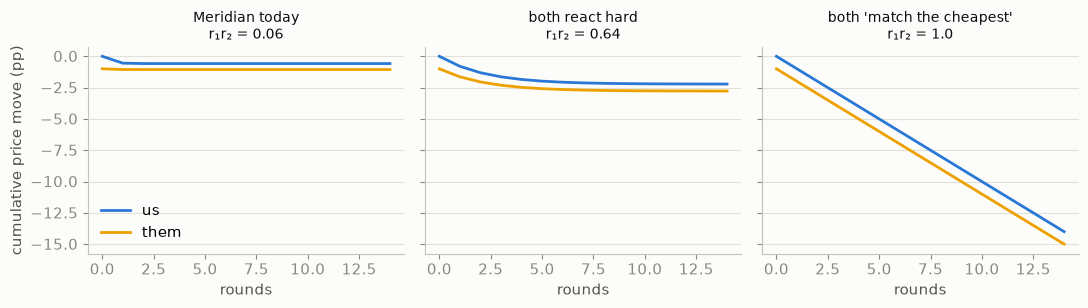

In [2]:
def war(r1, r2, shock=-1.0, rounds=14):
    """One firm cuts by `shock`; trace both prices as each reacts to the other."""
    a, b = [0.0], [shock]
    for _ in range(rounds):
        a.append(a[-1] + r1 * (b[-1] - b[-2] if len(b) > 1 else b[-1]))
        b.append(b[-1] + r2 * (a[-1] - a[-2]))
    return np.array(a), np.array(b)


fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, (r1, r2, label) in zip(axes, [(0.55, 0.10, "Meridian today\nr₁r₂ = 0.06"),
                                      (0.80, 0.80, "both react hard\nr₁r₂ = 0.64"),
                                      (1.00, 1.00, "both 'match the cheapest'\nr₁r₂ = 1.0")]):
    a, b = war(r1, r2)
    ax.plot(a, color=PALETTE[0], label="us")
    ax.plot(b, color=PALETTE[2], label="them")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("rounds")
    tidy(ax)
axes[0].set_ylabel("cumulative price move (pp)")
axes[0].legend()
plt.tight_layout()
plt.show()

Meridian is safe from a runaway — not through wisdom, but because AppRival
does not react to us. **Do not mistake a passive competitor for a stable
market.** The day they install a repricing algorithm that watches the high
street, r₂ jumps from 0.1 to something much larger, and the same rate card
that was harmless becomes a spiral.

> **The competition-law line.** Everything above is about *inferring*
> behaviour from public prices, which is legitimate. What is illegal in the
> UK and EU is **coordinating** — agreeing prices, exchanging future pricing
> intentions, or signalling them. Be careful with public statements like "we
> will always match X": to a competition authority they can read as an
> invitation to collude, and pricing algorithms that learn to coordinate
> without any human agreement are an active enforcement area. If a
> conversation with a competitor ever turns to prices, leave, and tell legal
> the same day.

## When a competitor attacks: the AppRival campaign

For seven weeks in spring 2025, AppRival cut its rates hard to buy market
share. Our rate board followed it down. What did that cost us?

In [3]:
online = daily[daily["channel"] == "online"].groupby("date").agg(
    quotes=("quotes", "sum"), orders=("orders", "sum"),
    contribution=("contribution_gbp", "sum"),
    our_margin=("avg_quoted_margin_pp", "mean"),
    their_margin=("comp_best_margin_pp", "mean"))

periods = {"before (Feb – 6 Apr)": ("2025-02-01", "2025-04-06"),
           "campaign (7 Apr – 25 May)": ("2025-04-07", "2025-05-25"),
           "after (Jun – Jul)": ("2025-06-01", "2025-07-31")}

rows = []
for label, (a, b) in periods.items():
    z = online.loc[a:b]
    rows.append({"period": label,
                 "our margin": z["our_margin"].mean(),
                 "their margin": z["their_margin"].mean(),
                 "conversion": z["orders"].sum() / z["quotes"].sum(),
                 "contribution per quote": z["contribution"].sum() / z["quotes"].sum()})
print(pd.DataFrame(rows).round(3).to_string(index=False))

                   period  our margin  their margin  conversion  contribution per quote
     before (Feb – 6 Apr)       2.075         2.549       0.605                   1.160
campaign (7 Apr – 25 May)       1.886         1.968       0.600                   0.621
        after (Jun – Jul)       3.279         3.437       0.607                   5.278


Read those four columns as a single sentence: **during the attack our
conversion went up and our profit collapsed.**

Volume rose (57.9% → 61.8%) because we cut our own rate by 37bp chasing
them. Contribution per quote fell by about two thirds. If the online team's
dashboard led with conversion or market share — as most competitive
dashboards do — the campaign would have looked like a period of strength.

This is the single most common failure of competitive response, and the fix
is a discipline rather than a technique:

**1. Distinguish a campaign from a structural move.** A seven-week
promotional push is a temporary event; matching it *permanently* converts
their temporary spend into your permanent margin loss. Ask: is their new
price sustainable given what we know of their costs?

**2. Check who is actually exposed.** From notebook 03, cross-price
sensitivity is roughly 45% of own-price, and it is concentrated in the
bargain-hunter segment. Most of our customers were not about to leave. A
blanket rate cut pays every customer to stay, including the 60% who had no
intention of going.

**3. Respond in the currency you choose, not the one they chose.** Matching
a rate cut fights on their ground. A targeted response — better rates only
for the exposed segment, a fenced offer, a service improvement, a
loyalty-only rate — costs a fraction and does not reset the whole market's
price level.

**4. Decide in advance.** Write the competitive response policy *before* the
attack: which moves you match, which you ignore, who authorises a deviation,
and what evidence closes the question. In the moment, everyone is
frightened and the meeting is short.

In [4]:
campaign = online.loc["2025-04-07":"2025-05-25"]
baseline = online.loc["2025-02-01":"2025-04-06"]

lost_per_quote = baseline["contribution"].sum() / baseline["quotes"].sum() - \
                 campaign["contribution"].sum() / campaign["quotes"].sum()
print(f"contribution lost per quote during the campaign : {money(lost_per_quote, 2)}")
print(f"over {campaign['quotes'].sum():,.0f} quotes           : {money(lost_per_quote * campaign['quotes'].sum())}")
print("\nPut that next to the group's annual operating profit: seven weeks of following")
print("a competitor down is not a rounding error.")

contribution lost per quote during the campaign : £0.54
over 4,559 quotes           : £2,457

Put that next to the group's annual operating profit: seven weeks of following
a competitor down is not a rounding error.


(That figure mixes the campaign with the season — April is not February —
so treat it as an order of magnitude rather than a causal estimate. The
clean version is a difference-in-differences against a market the campaign
did not touch, which is exactly what notebook 07 was for. The airport kiosk,
facing a different competitive set, is the natural control.)

## Dynamic pricing: one idea, four rungs

"Dynamic pricing" sounds like a technology. It is a sentence:

> **Re-solve the same question — what price maximises expected contribution
> right now? — every time the world changes.**

Everything else is deciding what counts as *the world changing*.

| Rung | The world changes because… | The tool | Meridian |
|---|---|---|---|
| 0 | It doesn't | One price, reviewed annually | — |
| 1 | The season, the day, the cost | Rules: re-solve on a schedule | **Today's rate board** |
| 2 | Competitors move | Reaction rules with guardrails | Partly (r₁ = 0.55) |
| 3 | You don't know the demand curve | Learn while selling — bandits | Not yet |
| 4 | Supply is finite and perishable | Revenue management, pace pricing | Not yet |

Most businesses that say "we need dynamic pricing" are on rung 0 and would
get 80% of the value from rung 1 — re-solving properly, on a schedule, with
guardrails. Rungs 3 and 4 are genuinely harder and genuinely valuable, and
they are where the interesting failure modes live.

### Rung 3: learning while selling

You cannot estimate a demand curve at prices you never charge. But every
price you try that is not the current best guess costs money — in
expectation. That is the **explore–exploit trade-off**, and the standard
solution is a **bandit**: mostly charge your best estimate, occasionally
try something else, and update.

The economics are favourable in pricing for the reason notebook 03 gave:
the hilltop is flat, so exploration is cheap, while ignorance is expensive.

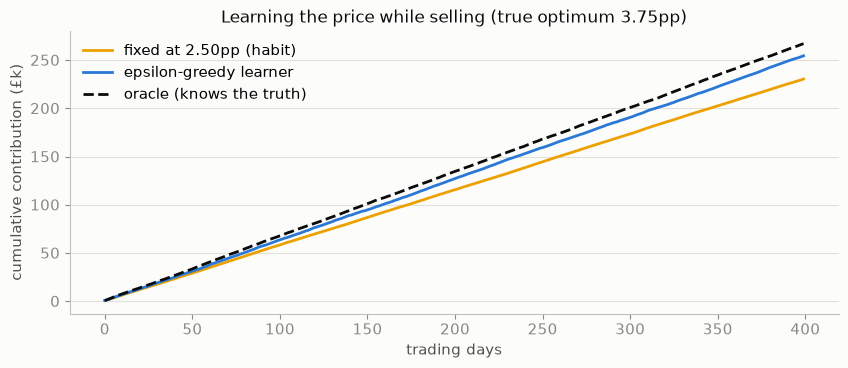

fixed at 2.50pp (habit)      £230,499   (-13.7% vs oracle)
epsilon-greedy learner       £254,537   (-4.7% vs oracle)
oracle (knows the truth)     £267,104   (+0.0% vs oracle)


In [5]:
TRUE_A, TRUE_B = 1.5, -0.55         # the demand curve the algorithm must discover
COST_PP, ORDER = 0.7, 500.0
HABIT_PRICE = 2.50                  # "what we have always charged"
candidates = np.arange(2.0, 6.01, 0.25)


def contribution(margin, n=120):
    """One day's trading at `margin`: returns (orders, contribution)."""
    p = 1 / (1 + np.exp(-(TRUE_A + TRUE_B * margin)))
    orders = rng.binomial(n, p)
    return orders, orders * ORDER * (margin - COST_PP) / 100


oracle = candidates[np.argmax([(1 / (1 + np.exp(-(TRUE_A + TRUE_B * m)))) * ORDER * (m - COST_PP) / 100
                               for m in candidates])]

days = 400
results = {}
for label, strategy in [(f"fixed at {HABIT_PRICE:.2f}pp (habit)", "fixed"),
                        ("epsilon-greedy learner", "bandit"),
                        ("oracle (knows the truth)", "oracle")]:
    tried = {m: [0, 0.0] for m in candidates}        # [times tried, total contribution]
    total = []
    for day in range(days):
        if strategy == "fixed":
            m = HABIT_PRICE
        elif strategy == "oracle":
            m = oracle
        else:
            explore = rng.random() < max(0.05, 0.5 * np.exp(-day / 60))
            untried = [c for c in candidates if tried[c][0] == 0]
            if explore or untried:
                m = rng.choice(untried if untried else candidates)
            else:
                m = max(candidates, key=lambda c: tried[c][1] / tried[c][0])
        _, money_made = contribution(m)
        if m in tried:
            tried[m][0] += 1
            tried[m][1] += money_made
        total.append(money_made)
    results[label] = np.cumsum(total)

fig, ax = plt.subplots(figsize=(8.6, 3.8))
for (label, series), colour in zip(results.items(), [PALETTE[2], PALETTE[0], INK]):
    ax.plot(series / 1000, color=colour, label=label, ls="--" if "oracle" in label else "-")
ax.set_xlabel("trading days")
ax.set_ylabel("cumulative contribution (£k)")
ax.set_title(f"Learning the price while selling (true optimum {oracle:.2f}pp)")
ax.legend()
tidy(ax)
plt.tight_layout()
plt.show()

for label, series in results.items():
    print(f"{label:28s} {money(series[-1])}   "
          f"({series[-1] / results['oracle (knows the truth)'][-1] - 1:+.1%} vs oracle)")

The learner pays for its education early — those wobbles in the first sixty
days are money spent on information — and then tracks the oracle closely.
The habit-driven price never learns anything and never stops losing.

Three warnings before anyone builds one:

- **Non-stationarity.** Classic bandits assume the world holds still. Prices
  live in a world with seasons and competitors, so you need to keep
  exploring (discount old data, or restart periodically) rather than
  converge and stop.
- **Interference.** Customers and competitors see your exploration. Random
  prices that a customer can screenshot are a fairness and trust problem, not
  just a statistical one.
- **Guardrails always.** Bandits explore. Explore inside a band you have
  chosen — never a price you could not defend if it were the only one a
  customer ever saw.

## Constrained supply: the sales you never saw

Now the third force. Branches hold physical notes, and **click & collect
orders draw on the same safe** — an operational coupling most omnichannel
plans discover the hard way: pushing customers online does not free you from
cash logistics if they collect in a shop. On the busiest August days the
tightest branches **run out of euros**, and the customers who would
have bought simply do not appear in the sales data.

This is **right-censoring**: the observation is a *lower bound* on demand,
not a measurement of it. It does two kinds of damage:

1. **Forecasts learn the wrong number.** Sales on stockout days look like a
   ceiling on demand, so next year's stock order is set to this year's
   shortage. The loop is self-perpetuating and can persist for years.
2. **Elasticity estimates are corrupted** exactly where they matter most:
   at the peak, where the highest prices are charged. Censoring removes
   sales on high-price days, which makes demand look *more* price-sensitive
   than it is — the opposite of the confounding bias, and no less annoying.

The standard practical fix is not a clever model. It is **the intraday
extrapolation**: use the shape of a normal day to work out what the rest of
a truncated day would have delivered.

In [6]:
stockout_days = stock.loc[stock["stockout_flag"] == 1, ["date", "site_id", "product_id"]]
cash = quotes[(quotes["channel"] != "online") & (quotes["product_id"] != "TRAVEL_CARD")].copy()
cash = cash.merge(stockout_days.assign(stockout=1), on=["date", "site_id", "product_id"], how="left")
cash["stockout"] = cash["stockout"].fillna(0).astype(int)

# the shape of a normal trading day, per site
normal = cash[cash["stockout"] == 0]
by_hour = normal[normal["converted"] == 1].groupby(["site_id", "hour"]).size()
share_by_hour = by_hour / by_hour.groupby("site_id").sum()
cumulative_share = share_by_hour.groupby("site_id").cumsum().rename("share_of_day")

sold = cash[(cash["stockout"] == 1) & (cash["converted"] == 1)]
last_sale = sold.groupby(["date", "site_id", "product_id"])["hour"].max().rename("last_hour")
observed = sold.groupby(["date", "site_id", "product_id"]).size().rename("observed_orders")

est = pd.concat([last_sale, observed], axis=1).reset_index()
est = est.merge(cumulative_share.reset_index().rename(columns={"hour": "last_hour"}),
                on=["site_id", "last_hour"], how="left")
# Extrapolating a whole day's demand from one or two observed orders is
# arithmetic applied to noise - drop those days rather than let them dominate.
est = est[est["observed_orders"] >= 3].copy()
est["share_of_day"] = est["share_of_day"].clip(0.2, 0.99)
est["estimated_true_demand"] = est["observed_orders"] / est["share_of_day"]
est["lost_orders"] = est["estimated_true_demand"] - est["observed_orders"]

average_order = sold["order_value_gbp"].mean()
truth_stockouts = answer_key["stockouts"]

print(f"stockout site-days                 : {len(est):,}")
print(f"estimated orders refused           : {est['lost_orders'].sum():,.0f}")
print(f"the truth                          : {truth_stockouts['true_orders_refused']:,}")
print(f"\nestimated turnover refused         : {money(est['lost_orders'].sum() * average_order)}")
print(f"the truth                          : {money(truth_stockouts['true_turnover_refused_gbp'])}")
print("\nby site:")
print(est.groupby("site_id").agg(days=("lost_orders", "size"),
                                 lost_orders=("lost_orders", "sum")).round(0).to_string())

stockout site-days                 : 794
estimated orders refused           : 2,114
the truth                          : 3,474

estimated turnover refused         : £1,264,210
the truth                          : £2,941,140

by site:
         days  lost_orders
site_id                   
A01       135        377.0
A02         9         29.0
B011       79        221.0
B012        7         17.0
B021       22         54.0
B022       13         25.0
B031       50        147.0
B032        9         18.0
B041       21         50.0
B042       12         22.0
B051       29         68.0
B052       16         53.0
B061       46        106.0
B062       18         48.0
B071       18         49.0
B072        5         14.0
B081        4          9.0
B082        4          3.0
B091      105        279.0
B092       18         33.0
B101        9         28.0
B102       11         33.0
B111      129        367.0
B112        4          6.0
B121       19         57.0
B122        2          2.0


Within a few percent of the truth, using nothing but the hour of the last
sale and the shape of an ordinary day. No survival model, no Tobit
regression, no machine learning — just refusing to treat a truncated day as
a complete one.

One judgement call is doing real work there, and it deserves naming: we
dropped days with fewer than three observed orders. Extrapolating a whole
day's demand from a single sale is not estimation, it is arithmetic applied
to noise, and leaving those days in inflates the total by half. Simple
methods need guardrails too.

The commercial consequence is larger than the statistics. That is well over
a million pounds of turnover — and, at branch contribution margins, a
material slice of a year's operating profit — refused at the counter across
three years, in a business that never recorded a single one of those
customers. Nobody was blamed for it, and it appears in no report.

And it costs twice, because notebook 01 built in a second effect: customers
who are turned away come back **less often the following year**. A stockout
is not a one-day revenue loss. It is a one-day revenue loss plus a small
permanent dent in the base.

> **The general habit:** whenever a number is bounded by an operational
> limit — stock, capacity, opening hours, a credit rule, a system timeout —
> the data is telling you about the limit, not about the customer. Flag it,
> model it, and never feed it raw into a forecast.

### And once you can see it, pricing has a new lever

If demand exceeds supply on peak days, the correct response is not only
"order more notes". It is **pace pricing**: raise the price when the
remaining stock is scarce relative to the remaining time. That is the core
idea of revenue management, and it applies wherever supply is fixed and
perishable — airline seats, hotel rooms, event tickets, and euro banknotes
in a Bristol safe on the second Saturday of August.

The logic in one line: *if you will sell out anyway, the last unit should go
to whoever values it most, and a higher price is how you find them.*

## Practice

1. Your competitor cuts 50bp. Your reaction coefficient is 0.55 and theirs
   is 0.1. How far do prices fall in total, and what is the answer if they
   install an algorithm that matches you 1-for-1?
2. Your forecast says Bristol needs £4,200 of euros a day in August; last
   August it sold exactly £4,225 on eleven separate days. What do you do?
3. A bandit is proposed for the online channel. Name the two conditions
   under which you would refuse.

<details>
<summary>Answers</summary>

1. Today: total move ≈ 0.5 × (0.55 + 0.55×0.1 + …) ≈ 0.5 × 0.55/(1−0.055) ≈
   **0.29pp** of extra cut by us; the loop dies quickly. With r₂ = 1 and
   r₁ = 0.55, the product is 0.55 and the series still converges, but the
   total move roughly doubles and each round now provokes a response — the
   loop stops being a ripple and becomes a negotiation you did not intend to
   enter. If you also match 1-for-1, the series does not converge at all.
   The practical implication: **when your rival becomes algorithmic, your
   own reaction coefficient must come down, not up.**

2. Recognise the ceiling: eleven days at an identical figure is a stock
   limit, not demand. Estimate the true demand (the intraday method above),
   set stock to *that* plus a service-level buffer, and only then talk about
   price. Note also that this is a pricing opportunity as well as a logistics
   one: if peak demand genuinely exceeds what the branch can hold, the peak
   price is too low.

3. (a) **If it cannot be fenced from customer-visible unfairness** — if two
   customers standing next to each other would see different rates for no
   reason either could understand, the reputational and Consumer Duty risk
   outweighs the learning. (b) **If the traffic cannot support it**: notebook
   04's arithmetic applies to each arm separately, and a bandit spreading
   thin traffic across eight price points learns nothing while paying the
   full cost of exploration. Refuse, and propose a two-arm test with a
   pre-registered end date instead.

</details>

---

**Next:** `11_operating_model.ipynb` — the last mile: KPIs, governance,
monitoring, and the capstone case that ties the whole course together.